# Lois de Snell-Descartes

**Correction de référence — valeurs expérimentales simulées mais cohérentes**

Noms : correction de référence  
Date de la séance : —  

Ce notebook doit permettre à une personne qui n'a pas assisté au TP de comprendre les mesures réalisées, leur exploitation et les conclusions obtenues. Utilisez uniquement les données de votre binôme.

Avant le rendu, exécutez toutes les cellules dans l'ordre et vérifiez que les résultats et les graphes apparaissent.

<!-- snell-objectives-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectifs et principe

Reformulez les deux objectifs du TP et indiquez la loi physique qui sera mise à l'épreuve.

### Réponse :

On cherche à vérifier expérimentalement la loi de Snell-Descartes pour la réfraction et à déterminer l'indice du Plexiglas par plusieurs méthodes. La relation utilisée est $n_1\sin i_1=n_2\sin i_2$.

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

def deg(x):
    return np.asarray(x, dtype=float) * np.pi / 180

## Présentation du dispositif

Le montage comprend un disque gradué pivotant, un laser et un demi-cylindre de Plexiglas dont la face plane est placée sur un diamètre du disque. L'air est assimilé au vide.

Le faisceau doit atteindre le centre du disque. Sur la face courbe, il suit alors un rayon du demi-cylindre : l'incidence y est normale et cette face ne dévie pas le faisceau.

<!-- snell-setup-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Schéma et compréhension du montage

Insérez la photographie de votre propre schéma annoté, tracé sur une feuille sur la paillasse. Faites apparaître le laser, le demi-cylindre, la normale, les rayons utiles et les angles. Expliquez pourquoi le passage par le centre simplifie la lecture des angles.

### Réponse :

Le schéma personnel doit montrer le laser, le disque gradué, le demi-cylindre, la normale à la face plane et les rayons incident, réfléchi et réfracté avec leurs angles. Le faisceau passant par le centre suit un rayon du demi-cylindre : il arrive normalement sur la face courbe, n'y est pas dévié et la lecture des angles sur la face plane est simplifiée.

</div>

## 1. Première méthode : angle limite

On étudie le passage Plexiglas $\to$ air. À la limite de réflexion totale :

$$\sin i_l = \frac{1}{n} \qquad\text{donc}\qquad n = \frac{1}{\sin i_l}$$.

<!-- critical-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Protocole de mesure de l'angle limite

Décrivez comment vous repérez l'apparition de la réflexion totale, mesurez $i_l$ et estimez l'incertitude-type $u(i_l)$. Mentionnez les principales difficultés de lecture.

### Réponse :

On place le montage dans le sens Plexiglas vers air puis on augmente progressivement l'incidence. L'angle limite est relevé lorsque le rayon transmis disparaît et que la réflexion totale apparaît. Plusieurs approches de part et d'autre de la transition permettent d'encadrer $i_l$. La graduation et le caractère progressif de la disparition conduisent ici à $u(i_l)=0,5°$.

</div>

In [2]:
# Repère TPStudio historique : il= ? #degrés
# Repère TPStudio historique : n=1/np.sin(il)
# Mesures du binôme, en degrés
il_deg = 42.2
uil_deg = 0.5

assert il_deg is not None and uil_deg is not None, "Compléter il_deg et uil_deg."

N = 50000
il = np.random.normal(deg(il_deg), deg(uil_deg), N)
n_direct_samples = 1 / np.sin(il)

n1 = n_direct_samples.mean()
un1 = n_direct_samples.std(ddof=1)

# Choisir le nombre de décimales conformément au TP-cours Incertitudes.
decimales_n1 = 2
print("n par angle limite =", round(n1, decimales_n1), "+/-", round(un1, decimales_n1))

n par angle limite = 1.49 +/- 0.01


<!-- direct-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat — Première méthode de mesure de l'indice

Écrivez le résultat avec une incertitude correctement arrondie, puis commentez sa précision, les difficultés expérimentales et sa cohérence avec une valeur documentée pour le Plexiglas.

### Réponse :

On obtient un indice voisin de $1,49$ avec une incertitude de l'ordre de $0,01$. La méthode est assez précise, mais le repérage exact de la disparition du rayon réfracté reste délicat. Le résultat est cohérent avec les valeurs usuelles de l'indice du Plexiglas, proches de 1,49.

</div>

## 2. Seconde méthode : un couple d'angles

Pour une réfraction air $\to$ Plexiglas :

$$n = \frac{\sin i_1}{\sin i_2}$$

<!-- single-pair-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Protocole avec un couple d'angles

Décrivez la mesure de $i_1$ et $i_2$. Justifiez le choix d'un angle d'incidence « bien choisi » et les incertitudes-types retenues.

### Réponse :

On replace le montage dans le sens air vers Plexiglas. On choisit $i_1=50,0°$ : l'angle est assez grand pour limiter l'effet relatif des incertitudes, sans rendre la lecture ambiguë. On mesure alors $i_2=30,9°$. La demi-graduation et la largeur des rayons conduisent à retenir $u(i_1)=u(i_2)=0,5°$.

</div>

In [3]:
# Repères TPStudio historiques : i1 = ?*np.pi/180 et i2 = ?*np.pi/180
# Repère TPStudio historique : n=np.sin(i1)/np.sin(i2)
# Repère TPStudio historique : En=abs(n.mean()-n0)
# Mesures du binôme, en degrés
i1_deg = 50.0
ui1_deg = 0.5
i2_deg = 30.9
ui2_deg = 0.5

assert None not in [i1_deg, ui1_deg, i2_deg, ui2_deg], "Compléter les quatre valeurs."

N = 50000
i1 = np.random.normal(deg(i1_deg), deg(ui1_deg), N)
i2 = np.random.normal(deg(i2_deg), deg(ui2_deg), N)
n_geometric_samples = np.sin(i1) / np.sin(i2)

n2 = n_geometric_samples.mean()
un2 = n_geometric_samples.std(ddof=1)
En12 = abs(n2 - n1) / np.sqrt(un2**2 + un1**2)

decimales_n2 = 2
print("n par un couple d'angles =", round(n2, decimales_n2), "+/-", round(un2, decimales_n2))
print("Écart normalisé entre les méthodes 1 et 2 =", round(En12, 2))

n par un couple d'angles = 1.49 +/- 0.02
Écart normalisé entre les méthodes 1 et 2 = 0.11


<!-- single-pair-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat — Seconde méthode de mesure de l'indice

Donnez $n$ avec son incertitude, puis utilisez la valeur de l'écart normalisé et le seuil 2 pour conclure sur la compatibilité avec la première méthode. Discutez une cause expérimentale plausible en cas d'écart.

### Réponse :

La seconde méthode donne un indice voisin de $1,49$ avec une incertitude d'environ $0,03$. L'écart normalisé entre les deux premières méthodes est inférieur à 2 : les résultats sont compatibles. La lecture de seulement deux angles explique que cette méthode soit moins précise.

</div>

## 3. Vérification graphique de la loi de la réfraction

Relevez **au moins quinze couples** $(i_1,i_2)$. Si la loi de Snell-Descartes est vérifiée pour air $\to$ Plexiglas, les points représentant $\sin i_1$ en fonction de $\sin i_2$ doivent suivre :

$$\sin i_1 = n\sin i_2.$$

La pente de la droite donne alors une estimation de $n$.

<!-- series-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Protocole de la série angulaire

Expliquez comment vous choisissez et relevez au moins quinze couples d'angles, en conservant la même géométrie et les mêmes conventions de lecture.

### Réponse :

On conserve le même centrage et les mêmes conventions de lecture. On fait varier l'incidence de 0° à 70° et on relève au moins quinze couples $(i_1,i_2)$ répartis sur toute la plage utile. Pour chaque position, on vérifie le passage du faisceau par le centre avant de lire les angles.

</div>

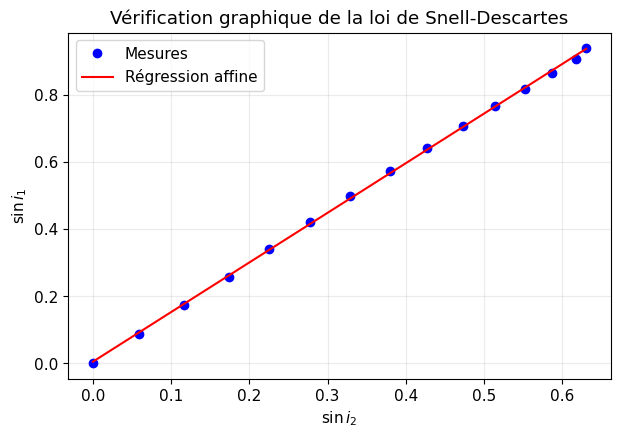

Pente a = 1.48
Ordonnée à l'origine b = 0.005


In [4]:
# Vérification de la loi de la réfraction
# Vérification graphique
# Affichage de l'équation de la droite
# Remplacer les ? et les points de suspension par toutes les mesures du binôme.
i1_deg_liste = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70], dtype=float)
i2_deg_liste = np.array([0, 3.4, 6.7, 10.0, 13.0, 16.1, 19.2, 22.3, 25.3, 28.2, 30.9, 33.5, 35.9, 38.1, 39.1], dtype=float)

assert len(i1_deg_liste) == len(i2_deg_liste), "Les deux listes doivent avoir la même longueur."
assert len(i1_deg_liste) >= 15, "Il faut au moins quinze couples de valeurs."

sini1 = np.sin(deg(i1_deg_liste))
sini2 = np.sin(deg(i2_deg_liste))
a, b = np.polyfit(sini2, sini1, 1)

plt.figure()
plt.plot(sini2, sini1, "bo", label="Mesures")
plt.plot(sini2, a * sini2 + b, "r-", label="Régression affine")
plt.xlabel(r"$\sin i_2$")
plt.ylabel(r"$\sin i_1$")
plt.title("Vérification graphique de la loi de Snell-Descartes")
plt.legend()
plt.show()

print("Pente a =", round(a, 3))
print("Ordonnée à l'origine b =", round(b, 3))

<!-- graph-analysis-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Analyse du graphe

Les points sont-ils alignés et l'ordonnée à l'origine est-elle compatible avec zéro ? Concluez sur la vérification de la loi de Snell-Descartes dans le domaine étudié, puis interprétez la pente.

### Réponse :

Les points représentant $\sin i_1$ en fonction de $\sin i_2$ sont alignés et l'ordonnée à l'origine est très proche de zéro. La loi de Snell-Descartes est donc vérifiée dans le domaine étudié. La pente de la droite représente l'indice du Plexiglas et vaut environ 1,49.

</div>

In [5]:
# Méthode statistique
# Détermination de n pour chaque couple non nul
masque = np.sin(deg(i2_deg_liste)) != 0
n_series = np.sin(deg(i1_deg_liste[masque])) / np.sin(deg(i2_deg_liste[masque]))
n3 = n_series.mean()
un3 = n_series.std(ddof=1)
En23 = abs(n3 - n2) / np.sqrt(un3**2 + un2**2)

decimales_n3 = 2
print("Valeurs de n =", np.round(n_series, decimales_n3))
print("n moyen =", round(n3, decimales_n3), "+/-", round(un3, decimales_n3))
print("Écart normalisé entre les méthodes 2 et 3 =", round(En23, 2))

Valeurs de n = [1.47 1.49 1.49 1.52 1.52 1.52 1.51 1.5  1.5  1.49 1.48 1.48 1.47 1.49]
n moyen = 1.5 +/- 0.02
Écart normalisé entre les méthodes 2 et 3 = 0.12


<!-- series-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Comparaison des résultats obtenus

Donnez le résultat moyen avec son incertitude. Commentez sa précision et utilisez l'écart normalisé pour le comparer à la seconde méthode.

### Réponse :

La moyenne des indices est voisine de $1,49$. La dispersion traduit principalement les incertitudes de lecture des angles. L'écart normalisé avec la seconde méthode est inférieur à 2 : les deux déterminations sont compatibles. La série de mesures rend également visible la validité du modèle sur une large plage d'incidences.

</div>

<!-- final-conclusion-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Conclusion / bilan

Répondez aux objectifs : vérification expérimentale de la loi, valeurs de l'indice obtenues et valeur finalement retenue. Présentez les principales limites expérimentales et une amélioration possible du protocole.

### Réponse :

L'alignement des points et l'ordonnée à l'origine proche de zéro vérifient expérimentalement la loi de Snell-Descartes. Les trois méthodes donnent des indices compatibles ; on retient une valeur voisine de $n=1,49$. Les principales limites sont le centrage du faisceau, son épaisseur et la lecture des graduations. Une amélioration serait de répéter chaque lecture ou d'utiliser une acquisition d'image pour repérer plus précisément la direction des rayons.

</div>

## Liste d'auto-vérification avant rendu

- [ ] Les noms et la date sont indiqués.
- [ ] Le schéma personnel est inséré et légendé.
- [ ] Les protocoles et les incertitudes sont justifiés.
- [ ] Les valeurs d'exemple ont toutes été remplacées par celles du binôme.
- [ ] Toutes les cellules ont été exécutées dans l'ordre.
- [ ] Les axes du graphe sont nommés et la légende est visible.
- [ ] Les résultats sont arrondis conformément au TP-cours Incertitudes.
- [ ] Les écarts normalisés sont interprétés avec le seuil 2.
- [ ] La conclusion répond aux deux objectifs.